# double_ITCZ_bias: Meridional structure of time-mean precipitation (PR) in the eastern Pacific

The meridional structure of time-mean precipitation (PR) in the eastern Pacific, in the context of ENSO (El Niño-Southern Oscillation), refers to the distribution and variation of average precipitation along the north-south (meridional) direction over a certain period, usually during different ENSO phases (El Niño, La Niña, and neutral conditions).

This notebook computes the meridional root mean square error (RMSE) of climatological precipitation (PR) between model simulations and observations over the eastern Pacific region (15°S-15°N, 150°W-90°W). 

The analysis involves:
- Averaging precipitation data zonally between 150°W and 90°W.
- Time-averaging the precipitation data to create climatologies for both model output and observational data.
- Calculating the meridional RMSE to quantify how well the model captures the observed precipitation pattern in this region.







## Observations and reanalysis datasets used for comparison

The following reference observational datasets are used to evaluate the model simulations:

- **GPCPv2.3 (1979-2018)**: The primary dataset for comparison. The Global Precipitation Climatology Project (GPCP) combines satellite and surface precipitation measurements to provide comprehensive global precipitation data.
  
Additional observational datasets used for comparison include:
- **20CRv2 (1871-2012)**: The 20th Century Reanalysis provides global atmospheric data, including precipitation, based on surface pressure observations and ensemble assimilation techniques.
- **CMAP (1979-2018)**: The CPC Merged Analysis of Precipitation (CMAP) is a blend of gauge and satellite observations, offering global precipitation estimates.
- **ERA-Interim (1979-2018)**: Reanalysis data produced by the European Centre for Medium-Range Weather Forecasts (ECMWF), providing atmospheric variables, including precipitation, based on a large-scale model and historical observations.
- **NCEP2 (1979-2018)** also known as **NCEP-DOE R2**: The second generation of the National Centers for Environmental Prediction (NCEP) reanalysis, offering precipitation and other atmospheric variables.

These datasets provide a range of perspectives on precipitation patterns, helping to assess the model’s performance more robustly.

## Dask Cluster

Start a cluster with multiple cores

In [1]:
from dask.distributed import Client, progress
client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that i

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 21,Total memory: 765.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43973,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33805,Total threads: 3
Dashboard: /proxy/38941/status,Memory: 109.29 GiB
Nanny: tcp://127.0.0.1:39765,


In [2]:
#This cell must be in all notebooks!
#It allows us to run all the notebooks at once, note that the following cell has a tag "parameters" which allows us to pass in arguments externally using papermill (see mkfigs.sh for details)

#parameters

### USER EDIT start
#esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json'
dpi=300
esm_file = "/scratch/p66/yz9299/SeptSpinUpA/pr_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_060201-079012.nc"

mylabel = "SeptSpinUpA"
startyear=610
endyear=790
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/scratch/{os.environ['PROJECT']}/{os.environ['USER']}/nesp/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM path:  /scratch/p66/yz9299/SeptSpinUpA/pr_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_060201-079012.nc
Plot folder path:  /scratch/eg3/cxc548/nesp/


## Datasets

In [3]:
#import iris
from esmvalcore.dataset import Dataset

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/esmvalcore/config/_config_object.py:663: ESMValCoreDeprecationWarning: Usage of the single configuration file ~/.esmvaltool/config-user.yml or specifying it via CLI argument `--config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. To switch to the new configuration system, (1) run `mkdir -p ~/.config/esmvaltool && mv /home/548/cxc548/.esmvaltool/config-user.yml ~/.config/esmvaltool` (or alternatively use a custom `--config_dir`) and omit `--config_file`, or (2) use the environment variable ESMVALTOOL_CONFIG_DIR to specify a custom user configuration directory. New configuration files present at ~/.config/esmvaltool or specified via `--config_dir` are currently ignored.
  config_obj.reload()
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:452: ESMValCoreDeprecationWarning:

In [4]:
# # ACCESS MOPPeR ESM1.6
# import glob
# from access_mopper import ACCESS_ESM_CMORiser

# ROOT_FOLDER = (
#     "/g/data/p73/archive/CMIP7/ACCESS-ESM1-6/spinup/SeptSpinUpB-SeptSpinUpB-bfaa9c5b/"
# )

# OUTPUT_FOLDER = "/scratch/nf33/fc6164/"

# parent_experiment_config = {
#     "parent_experiment_id": "piControl",
#     "parent_activity_id": "CMIP",
#     "parent_source_id": "ACCESS-ESM1-5",
#     "parent_variant_label": "r1i1p1f1",
#     "parent_time_units": "days since 0001-01-01 00:00:00",
#     "parent_mip_era": "CMIP6",
#     "branch_time_in_child": 0.0,
#     "branch_time_in_parent": 54786.0,
#     "branch_method": "standard",
# }

In [5]:
model_ctrldatasets = {
"ACCESS-ESM1-5": 
    Dataset(
    short_name='pr',
    project='CMIP6',
    mip="Amon",
    exp="piControl",
    ensemble="r1i1p1f1",
    timerange="09000101/11000101",
    dataset="ACCESS-ESM1-5",
    grid="gn"
)}

obs_datasets = {
"GPCP-SG": 
    Dataset(
    short_name='pr',
    dataset='GPCP-SG',
    mip="Amon",
    project='OBS',
    type='atmos',
    timerange="19790101/20190101",
    tier=2),
# "NOAA-CIRES-20CR-V2": 
#     Dataset(
#     short_name='pr',
#     dataset='NOAA-CIRES-20CR-V2',
#     mip="Amon",
#     project='OBS6',
#     type='reanaly',
#     timerange="187101/201212",
#     tier=2),
# "CMAP": 
#     Dataset(
#     short_name='pr',
#     dataset='CMAP',
#     mip="Amon",
#     project='OBS6',
#     type='reanaly',
#     timerange="197901/202408",
#     tier=2),
## ERA-Interim not available in Tier2. Conctact NRI
# "ERA-Interim": 
#     Dataset(
#     short_name='pr',
#     dataset='ERA-Interim',
#     mip="Amon",
#     project='OBS6',
#     type='reanaly',
#     timerange="19790101/20190101",
#     tier=3)
}

## Add Ancillary files

In [6]:
for name, dataset in model_ctrldatasets.items():
    dataset.add_supplementary(short_name='sftlf', mip="fx")
    dataset.add_supplementary(short_name="areacella", mip="fx")

In [7]:
#print(esm16cube)
model_ctrldatasets = {name: dataset.load() for name, dataset in model_ctrldatasets.items()}
obs_datasets = {name: dataset.load() for name, dataset in obs_datasets.items()}

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:452: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, remove_version, more_info)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/esmvalcore/config/_config.py:59: ESMValCoreDeprecationWarning: Usage of extra facets located in ~/.esmvaltool/extra_facets has been deprecated in ESMValCore version 2.13.0 and is scheduled for removal in version 2.15.0. Please use the configuration option `extra_facets` instead (see https://github.com/ESMValGroup/ESMValCore/pull/2747 for details). To silent this warning and ignore deprecated extra facets, set the environment variable ESMVALTOOL_USE_NEW_EXTRA_FACETS_CON

In [8]:
import iris
from iris.util import equalise_attributes

#esm_file  = "/scratch/p66/yz9299/MOPPeR_outputs/CMIP6/CMIP/CSIRO/ACCESS-ESM1-6/piControl-spinup/r1i1p1f1/Amon/pr/gn/v20250801/*nc"

esm16cube = iris.load(esm_file,'precipitation_flux')
equalise_attributes(esm16cube)

esm16cube_concat = esm16cube.concatenate()


#print(esm16cube)
#model_datasets = {name:dataset.load() for name, dataset in esm16cube.items()}
print(esm16cube_concat)

0: precipitation_flux / (kg m-2 s-1)   (longitude: 192; latitude: 145; time: 2268)


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/fileformats/cf.py:664: IrisCfMissingVarWarning: Missing CF-netCDF grid mapping variable 'latitude_longitude', referenced by netCDF variable 'pr'
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/fileformats/cf.py:880: IrisCfMissingVarWarning: Missing CF-netCDF measure variable 'areacella', referenced by netCDF variable 'pr'
  warnings.warn(


In [9]:
from esmvalcore.preprocessor import annual_statistics
from esmvalcore.preprocessor import climate_statistics
from esmvalcore.preprocessor import convert_units
from esmvalcore.preprocessor import extract_region
from esmvalcore.preprocessor import extract_time
from esmvalcore.preprocessor import regrid
from esmvalcore.preprocessor import axis_statistics
from esmvalcore.preprocessor import mask_landsea

In [10]:
def preproc1(cube):
    nino3_latext_region = {"start_longitude": 150., "end_longitude": 270., "start_latitude": -15., "end_latitude": 15.}
    cube = extract_time(cube, start_year=1979, start_month=1, start_day=1, end_year=2014, end_month=12, end_day=31)
    cube = mask_landsea(cube, mask_out="land")
    cube = climate_statistics(cube, operator="mean", period="full")
    cube = convert_units(cube, units="mm/day")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino3_latext_region)
    return cube

def preproc2(cube):
    nino3_latext_region = {"start_longitude": 210., "end_longitude": 270., "start_latitude": -15., "end_latitude": 15.}
    cube = extract_time(cube, start_year=1979, start_month=1, start_day=1, end_year=2014, end_month=12, end_day=31)
    cube = convert_units(cube, units="mm/day")
    cube = mask_landsea(cube, mask_out="land")
    cube = climate_statistics(cube, operator="mean", period="full")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino3_latext_region)
    cube = axis_statistics(cube, operator="mean", axis="x")
    return cube

def preproc1_pi(cube,start,end):
    nino3_latext_region = {"start_longitude": 150., "end_longitude": 270., "start_latitude": -15., "end_latitude": 15.}
    cube = extract_time(cube, start_year=start, start_month=1, start_day=1, end_year=end, end_month=12, end_day=31)
    cube = mask_landsea(cube, mask_out="land")
    cube = climate_statistics(cube, operator="mean", period="full")
    cube = convert_units(cube, units="mm/day")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino3_latext_region)
    return cube

def preproc2_pi(cube,start,end):
    nino3_latext_region = {"start_longitude": 210., "end_longitude": 270., "start_latitude": -15., "end_latitude": 15.}
    cube = extract_time(cube, start_year=start, start_month=1, start_day=1, end_year=end, end_month=12, end_day=31)
    cube = convert_units(cube, units="mm/day")
    cube = mask_landsea(cube, mask_out="land")
    cube = climate_statistics(cube, operator="mean", period="full")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino3_latext_region)
    cube = axis_statistics(cube, operator="mean", axis="x")
    return cube


In [11]:
model_ctrldatasets_prep1 = {name: preproc1_pi(dataset,900,1100) for name, dataset in model_ctrldatasets.items()}

model_datasets_prep1 = preproc1_pi(esm16cube_concat[0],startyear,endyear)#{name: preproc1_pi(dataset) for name, dataset in esm16cube_concat[0]}
obs_datasets_prep1 = {name: preproc1(dataset) for name, dataset in obs_datasets.items()}

model_ctrldatasets_prep2 = {name: preproc2_pi(dataset,900,1100) for name, dataset in model_ctrldatasets.items()}

model_datasets_prep2 = preproc2_pi(esm16cube_concat[0],startyear,endyear)#{name: preproc2_pi(dataset) for name, dataset in esm16cube.items()}
obs_datasets_prep2 = {name: preproc2(dataset) for name, dataset in obs_datasets.items()}

# Diagnostics Level 1


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]


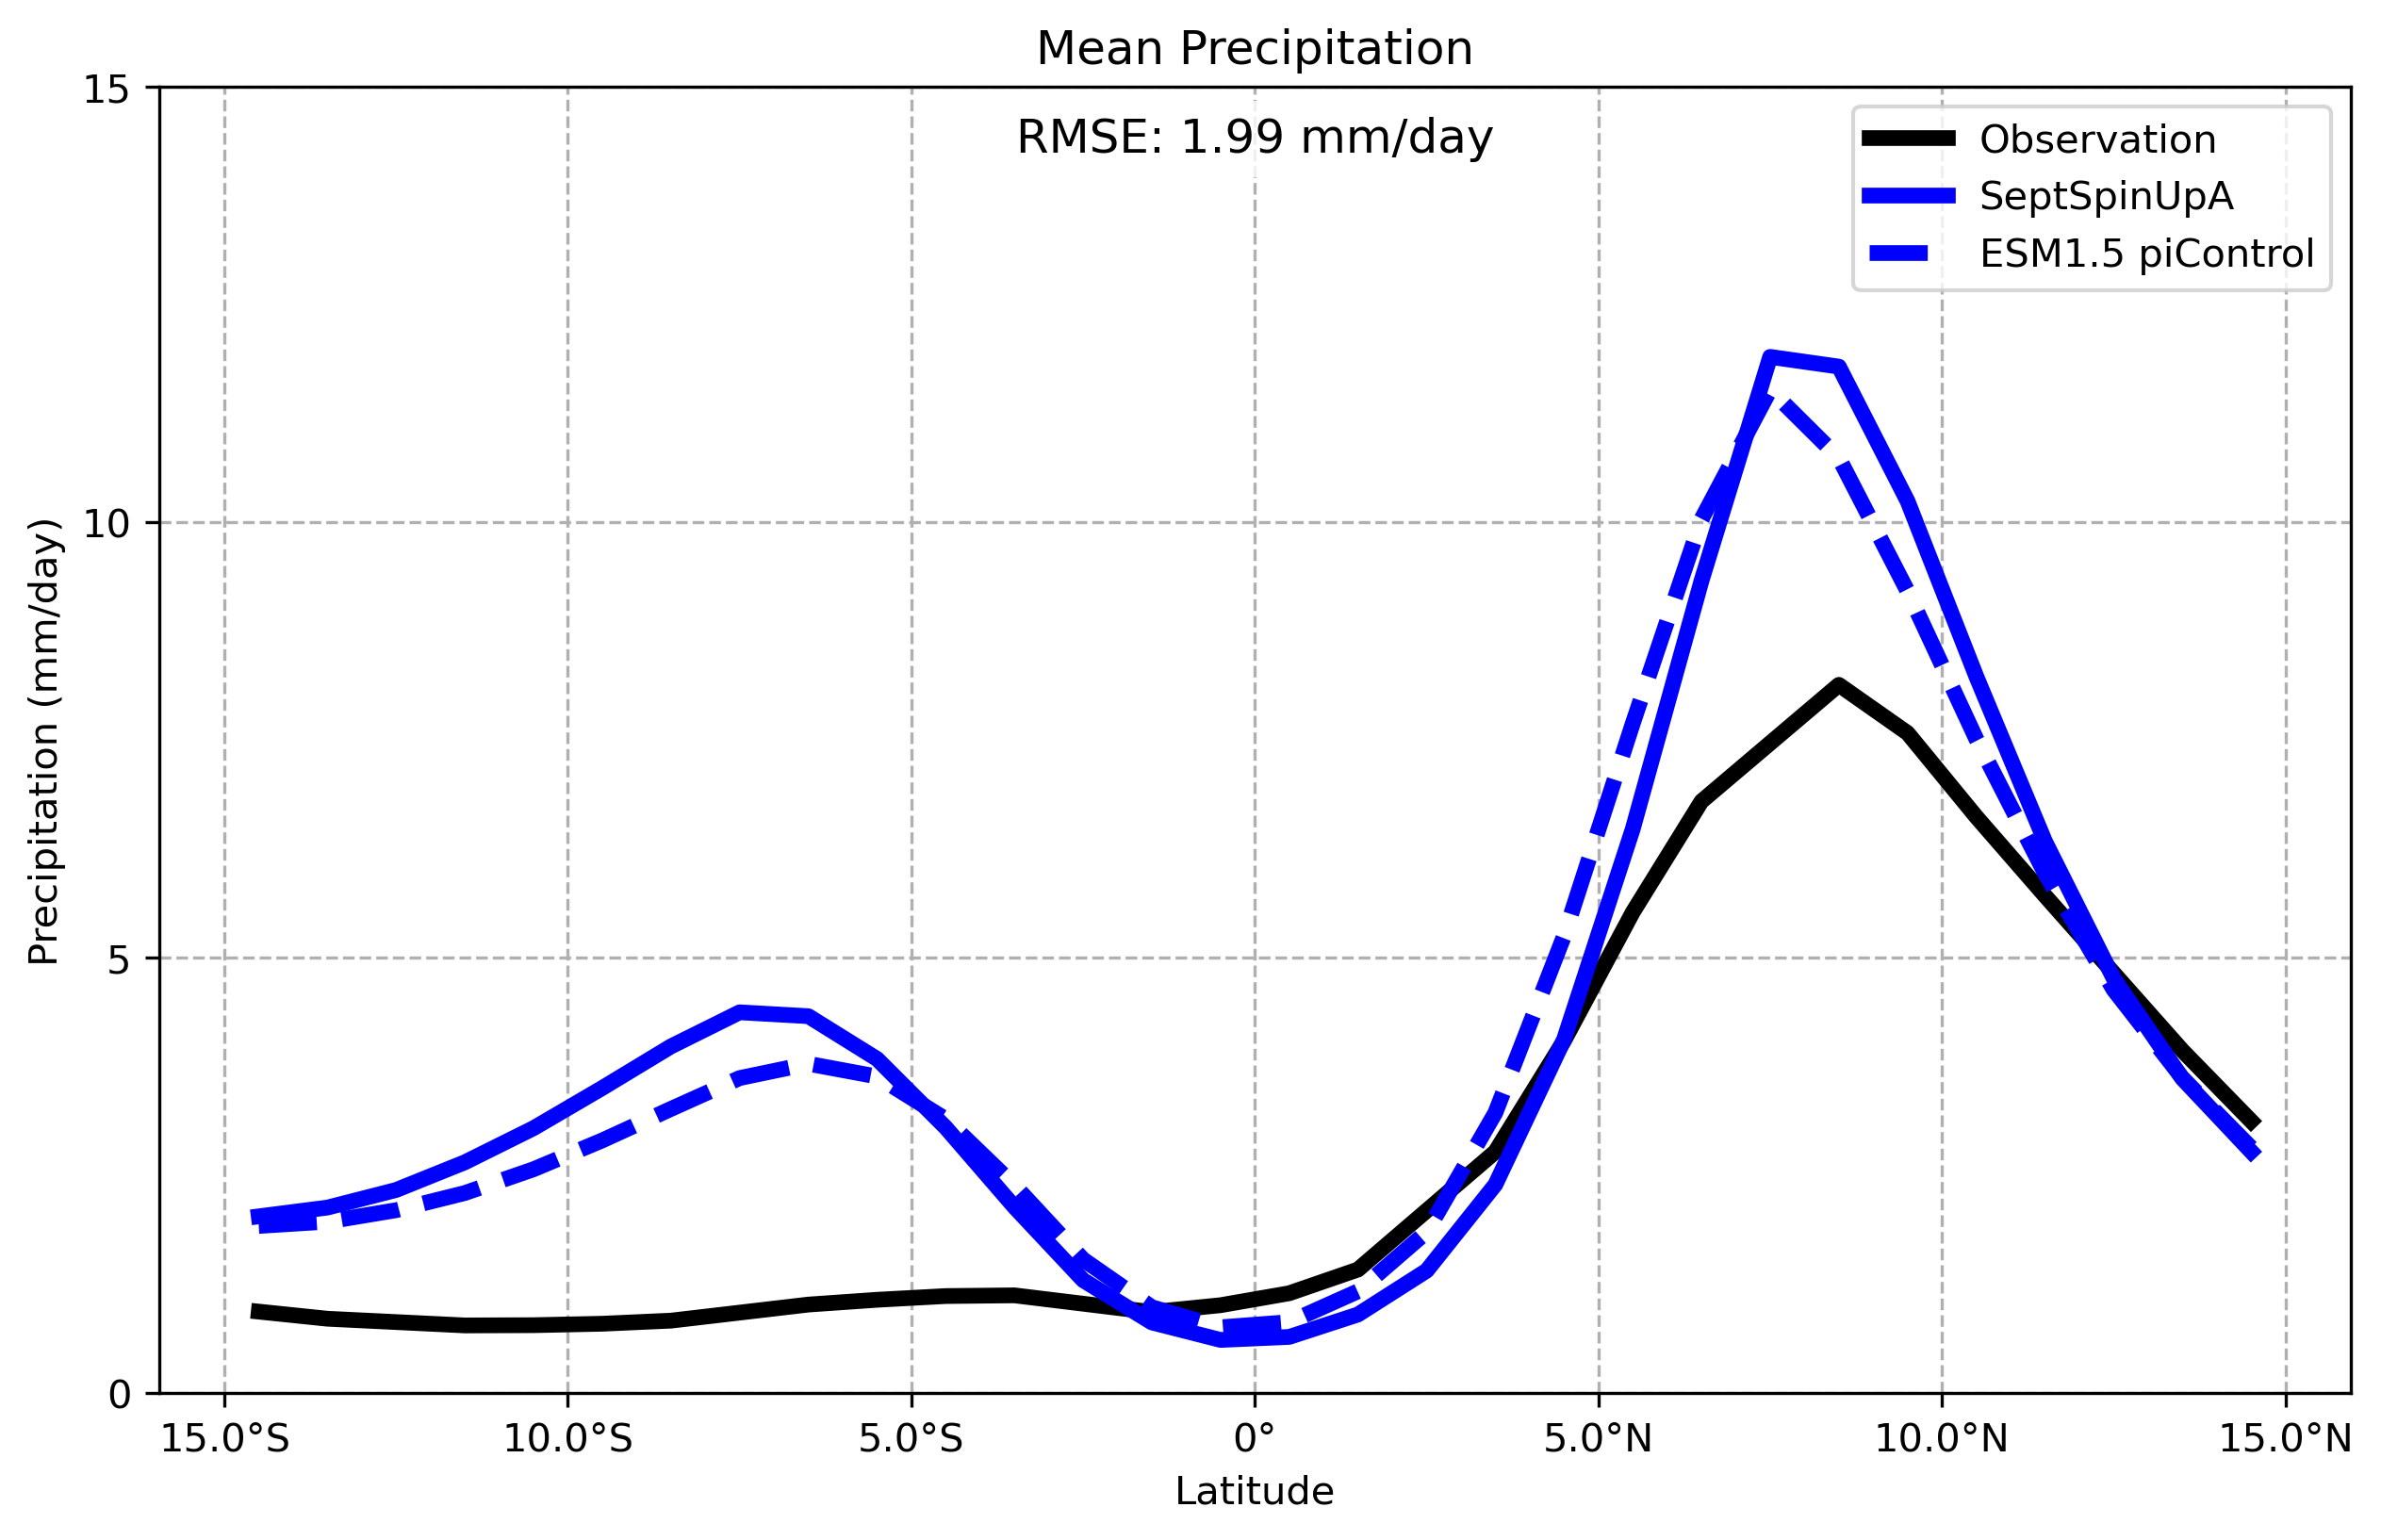

In [12]:
import iris
import iris.quickplot as qplt
import matplotlib.pyplot as plt
import numpy as np

# Function to format x-axis labels with degree symbols and N/S
def format_latitude(x, pos):
    if x < 0:
        return f'{abs(x)}°S'
    elif x > 0:
        return f'{x}°N'
    else:
        return '0°'

plt.figure(figsize=(10, 6))

obs_data = obs_datasets_prep2["GPCP-SG"]
model_data = model_datasets_prep2#["ACCESS-ESM1-5"]
model_ctrldata = model_ctrldatasets_prep2["ACCESS-ESM1-5"]

# Plot observation data in black
qplt.plot(obs_data, color='black', label='Observation', linewidth=4)

# Plot model data in blue
qplt.plot(model_data, color='blue', label=mylabel, linewidth=4)
qplt.plot(model_ctrldata, color='blue', label='ESM1.5 piControl', linewidth=4,linestyle='--')

rmse = np.sqrt(np.mean((obs_data.data - model_data.data) ** 2))

# Adding labels and title
plt.xlabel('Latitude')
plt.ylabel('Precipitation (mm/day)')
plt.title('Mean Precipitation')
plt.grid(linestyle='--')
plt.yticks(np.arange(0,16, step=5))


# Adding RMSE text on top of the plot
plt.text(0.5, 0.95, f'RMSE: {rmse:.2f} mm/day', fontsize=12, ha='center', transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Setting custom x-axis formatter
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_latitude))

# Adding a legend
plt.legend()

# Display the plot
plt.show()
#plt.savefig("/scratch/eg3/cxc548/nesp/ENSO_recipe01a.png", bbox_inches="tight", dpi=500)

Figure 1: Meridional bias in the time-mean precipitation (PR) structure across the eastern Pacific (averaged between 150–90°W), primarily illustrating the double intertropical convergence zone (ITCZ) bias. The black curve represents the reference data, while the blue curve represents the model data. The metric shown is the meridional RMSE between the model and reference curves.

# Diagnostics Level 2


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]


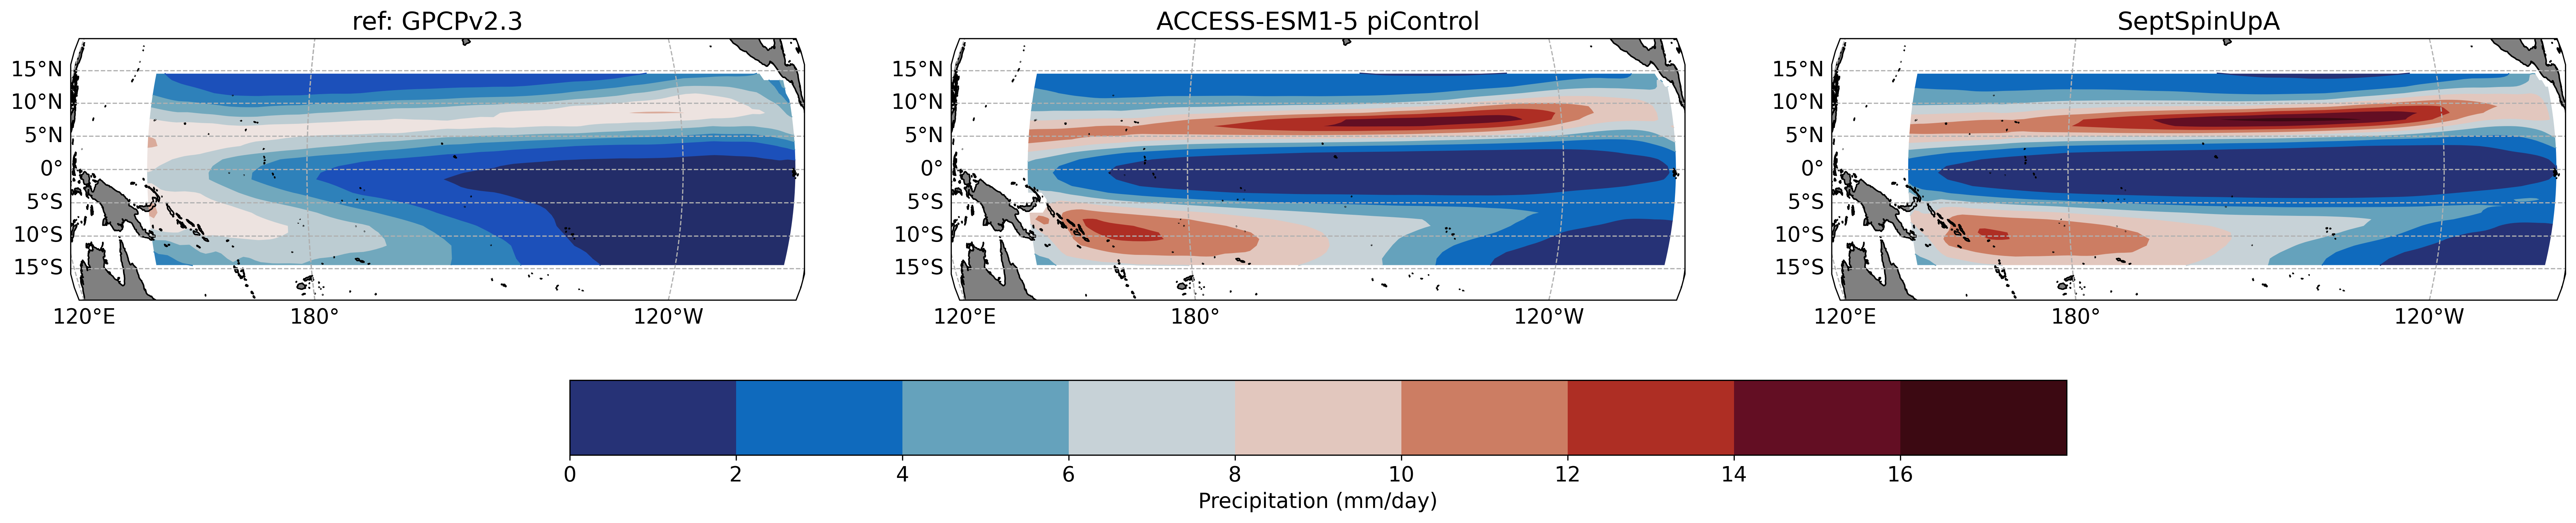

In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.colors as mcolors
import cmocean

# Importing numpy for linear space creation
import numpy as np

import iris
import iris.plot as iplt

obs_data = obs_datasets_prep1["GPCP-SG"]
model_data = model_datasets_prep1#["ACCESS-ESM1-5"]
model_ctrldata = model_ctrldatasets_prep1["ACCESS-ESM1-5"]

# Create a colormap from cmocean balance
vmin=0
vmax=16
cmap = cmocean.cm.balance
plt.rcParams.update({'font.size': 14})

# Create a large figure
fig = plt.figure(figsize=(30, 10))  # Adjusted for full width

# Center the map on the Pacific Ocean (roughly around 180° longitude)
proj = ccrs.Orthographic(central_longitude=-160, central_latitude=0)

# Define the normalization for the color scale with range of 0 to 12 mm

norm = mcolors.Normalize(vmin=vmin, vmax=vmax+2)

# Plot #1: contourf with axes longitude from -180 to 180
ax1 = plt.subplot(131, projection=proj)
cf1 = iplt.contourf(obs_data, cmap=cmap, vmin=vmin,vmax=vmax,levels=8)
ax1.add_feature(cfeature.LAND, facecolor='gray')  # Add land feature with gray color
ax1.coastlines()
ax1.set_extent([120, -80, -20, 20], crs=ccrs.PlateCarree())
ax1.set_title("ref: GPCPv2.3")

# Add gridlines for latitude and longitude
gl1 = ax1.gridlines(draw_labels=True, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False

# Plot #2: contourf with axes longitude from 0 to 360
ax2 = plt.subplot(132, projection=proj)
cf2 = iplt.contourf(model_ctrldata, cmap=cmap, vmin=vmin,vmax=vmax,levels=8)
ax2.add_feature(cfeature.LAND, facecolor='gray')  # Add land feature with gray color
ax2.coastlines()
ax2.set_extent([120, -80, -20, 20], crs=ccrs.PlateCarree())
ax2.set_title("ACCESS-ESM1-5 piControl")

# Add gridlines for latitude and longitude
gl2 = ax2.gridlines(draw_labels=True, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False

# Plot #3: contourf with axes longitude from 0 to 360
ax3 = plt.subplot(133, projection=proj)
cf3 = iplt.contourf(model_data, cmap=cmap, vmin=vmin,vmax=vmax,levels=8)
ax3.add_feature(cfeature.LAND, facecolor='gray')  # Add land feature with gray color
ax3.coastlines()
ax3.set_extent([120, -80, -20, 20], crs=ccrs.PlateCarree())
ax3.set_title(mylabel)

# Add gridlines for latitude and longitude
gl3 = ax3.gridlines(draw_labels=True, linestyle='--')
gl3.top_labels = False
gl3.right_labels = False

# Add a single colorbar at the bottom
cbar = fig.colorbar(cf3, ax=[ax1, ax2, ax3], orientation='horizontal', extend='both', pad=0.15, shrink=0.6)
cbar.set_label('Precipitation (mm/day)')
cbar.set_ticks(np.arange(vmin, vmax+2, 2))  # Set ticks at intervals of 2 mm

plt.subplots_adjust(bottom=0.3)  # Further adjust bottom margin to fit the colorbar
plt.show()
#plt.savefig("/scratch/eg3/cxc548/nesp/ENSO_recipe01b.png", bbox_inches="tight", dpi=500)

Figure 2: Time-mean precipitation (PR) bias in the equatorial Pacific, highlighting the double intertropical convergence zone (ITCZ) bias. The left map displays the reference data, while the right map shows the model data.